In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
data  = load_wine()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=13,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Explication locale (feature, poids):
[('color_intensity', -2.34380609568975), ('proline', -1.1767479582978089), ('alcohol', -1.1499316230516774), ('flavanoids', 0.9142894052325493), ('od280/od315_of_diluted_wines', 0.29739885539377214), ('hue', 0.165308498067662), ('alcalinity_of_ash', 0.035797574626865725), ('magnesium', -0.03513995247710022), ('malic_acid', 0.0), ('total_phenols', 0.0), ('ash', 0.0), ('nonflavanoid_phenols', 0.0), ('proanthocyanins', 0.0)]


In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=13
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('color_intensity', -0.11546867247086513), ('alcohol', -0.09484224750819567), ('proline', -0.08937829496114381), ('magnesium', -0.024381616990943048), ('hue', 0.024172442472845362), ('alcalinity_of_ash', 0.022173528760511495), ('malic_acid', -0.018041380379280225), ('flavanoids', 0.01707380134509967), ('total_phenols', -0.01452385100295307), ('ash', -0.011278345902694234), ('od280/od315_of_diluted_wines', 0.00814415369664384), ('proanthocyanins', 0.004428334503352236), ('nonflavanoid_phenols', 0.0035134573051856456)]


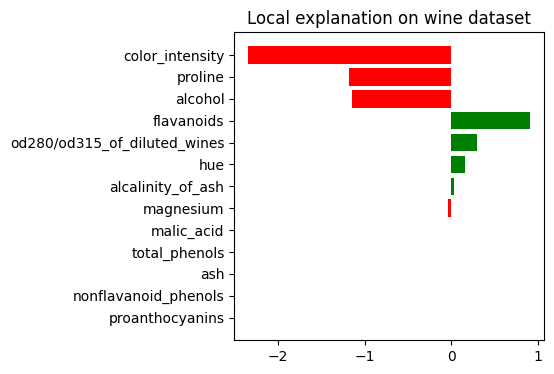

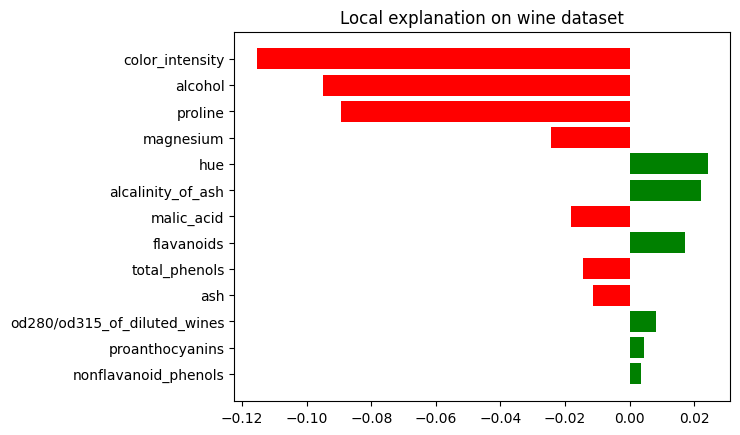

In [4]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on wine dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on wine dataset")
plt.show()


Local explanation with DecisionTreeRegressor surrogate (feature, weight):
[('color_intensity', -0.4736585834478058), ('alcohol', -0.317935362276011), ('proline', -0.2084060542761832), ('alcalinity_of_ash', 0.0), ('magnesium', -0.0), ('flavanoids', 0.0), ('od280/od315_of_diluted_wines', 0.0), ('malic_acid', -0.0), ('total_phenols', -0.0), ('nonflavanoid_phenols', -0.0), ('ash', -0.0), ('proanthocyanins', 0.0), ('hue', 0.0)]


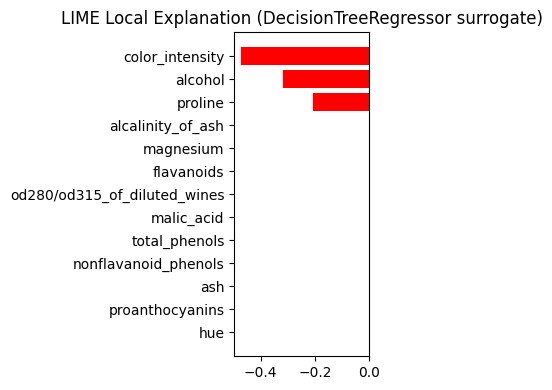

In [6]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# --- Custom wrapper class ---
class SignedDecisionTreeRegressorWrapper(DecisionTreeRegressor):
    """
    DecisionTreeRegressor wrapper for LIME that produces signed coefficients
    based on local feature–target correlations.
    """
    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        importances = np.array(self.feature_importances_)
        
        # Compute correlation signs between X_j and y
        signs = np.zeros_like(importances)
        for j in range(X.shape[1]):
            corr = np.corrcoef(X[:, j], y)[0, 1]
            signs[j] = np.sign(corr) if not np.isnan(corr) else 0
        
        # Combine magnitude (importance) with direction (sign)
        signed_importances = importances * signs
        
        # Normalize
        if np.sum(np.abs(signed_importances)) > 0:
            signed_importances = signed_importances / np.sum(np.abs(signed_importances))
        
        self.coef_ = signed_importances
        self.intercept_ = np.array([np.mean(y)])
        return self

# --- Instantiate and use in LIME ---
local_dt = SignedDecisionTreeRegressorWrapper(max_depth=3, random_state=0)

exp_dt = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=13,
    model_regressor=local_dt
)

print("\nLocal explanation with DecisionTreeRegressor surrogate (feature, weight):")
print(exp_dt.as_list())

fig_dt = exp_dt.as_pyplot_figure()
fig_dt.axes[0].set_title("LIME Local Explanation (DecisionTreeRegressor surrogate)")
plt.tight_layout()
plt.show()
